In [1]:
import akshare as ak
import pandas as pd
import os
# 获取贵州茅台近一年日线数据

df = ak.stock_zh_a_hist(symbol="600519", period="daily",
                         start_date="20260101", end_date="20260531")
df.to_csv("data/600519_data.csv", index=False)
print(df.head())
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

ProxyError: HTTPSConnectionPool(host='push2his.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/stock/kline/get?fields1=f1%2Cf2%2Cf3%2Cf4%2Cf5%2Cf6&fields2=f51%2Cf52%2Cf53%2Cf54%2Cf55%2Cf56%2Cf57%2Cf58%2Cf59%2Cf60%2Cf61%2Cf116&ut=7eea3edcaed734bea9cbfc24409ed989&klt=101&fqt=0&secid=1.600519&beg=20260101&end=20260531 (Caused by ProxyError('Unable to connect to proxy', RemoteDisconnected('Remote end closed connection without response')))

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/600519_data.csv")

# 日期列转为datetime类型，后面画图和计算都需要
df['日期'] = pd.to_datetime(df['日期'])

# 按日期排序（确保时间序列正确）
df = df.sort_values('日期').reset_index(drop=True)

# 检查是否有空值
print("空值检查：")
print(df.isnull().sum())
print(f"\n数据范围：{df['日期'].min()} 到 {df['日期'].max()}")
# 5日均线和20日均线（收盘价的滚动平均）
df['MA5'] = df['收盘'].rolling(window=5).mean()
df['MA20'] = df['收盘'].rolling(window=20).mean()

# 看一下结果，前几行MA会是NaN，这是正常的
print(df[['日期', '收盘', 'MA5', 'MA20']].head(25))
# 最大回撤：从某个高点到后续最低点的最大跌幅
df['滚动最高'] = df['收盘'].cummax()
df['回撤'] = (df['收盘'] - df['滚动最高']) / df['滚动最高'] * 100

max_drawdown = df['回撤'].min()
max_drawdown_date = df.loc[df['回撤'].idxmin(), '日期']

print(f"\n最大回撤：{max_drawdown:.2f}%")
print(f"发生日期：{max_drawdown_date}")
df['日期'] = df['日期'].dt.date

空值检查：
日期      0
股票代码    0
开盘      0
收盘      0
最高      0
最低      0
成交量     0
成交额     0
振幅      0
涨跌幅     0
涨跌额     0
换手率     0
dtype: int64

数据范围：2026-01-05 00:00:00 到 2026-05-29 00:00:00
           日期       收盘       MA5       MA20
0  2026-01-05  1426.00       NaN        NaN
1  2026-01-06  1428.01       NaN        NaN
2  2026-01-07  1423.36       NaN        NaN
3  2026-01-08  1412.30       NaN        NaN
4  2026-01-09  1419.10  1421.754        NaN
5  2026-01-12  1423.23  1421.200        NaN
6  2026-01-13  1411.00  1417.798        NaN
7  2026-01-14  1398.01  1412.728        NaN
8  2026-01-15  1388.89  1408.046        NaN
9  2026-01-16  1382.00  1400.626        NaN
10 2026-01-19  1376.00  1391.180        NaN
11 2026-01-20  1373.55  1383.690        NaN
12 2026-01-21  1351.06  1374.300        NaN
13 2026-01-22  1340.06  1364.534        NaN
14 2026-01-23  1337.00  1355.534        NaN
15 2026-01-26  1342.00  1348.734        NaN
16 2026-01-27  1343.01  1342.626        NaN
17 2026-01-28  1323.6

绘图收盘走势


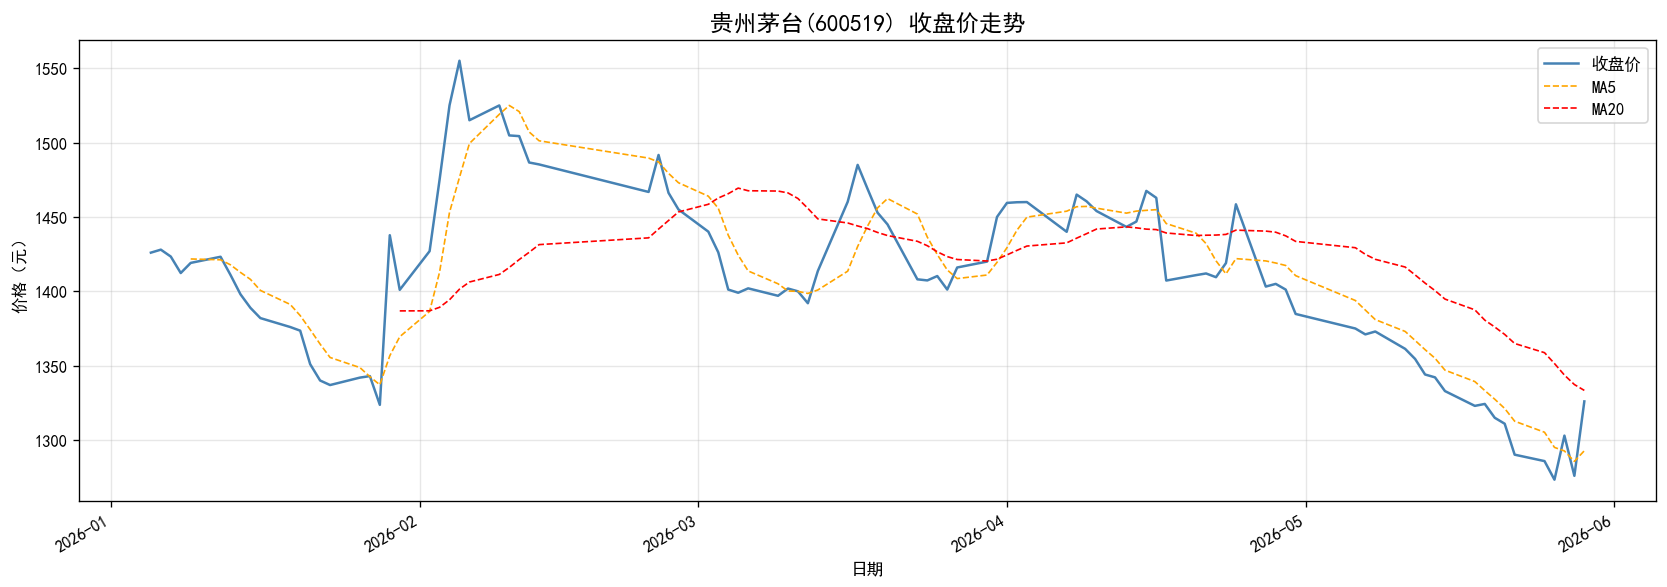

图表已保存


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
os.makedirs("data", exist_ok=True)
os.makedirs("output", exist_ok=True)
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(14, 5), dpi=120)

ax.plot(df['日期'], df['收盘'], label='收盘价', color='steelblue', linewidth=1.5)
ax.plot(df['日期'], df['MA5'], label='MA5', color='orange', linewidth=1, linestyle='--')
ax.plot(df['日期'], df['MA20'], label='MA20', color='red', linewidth=1, linestyle='--')

ax.set_title('贵州茅台(600519) 收盘价走势', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格（元）')
ax.legend()
ax.grid(True, alpha=0.3)

# 自动格式化x轴日期
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('output/price_trend.png', dpi=120)plt.show()
print("图表已保存")

成交量图

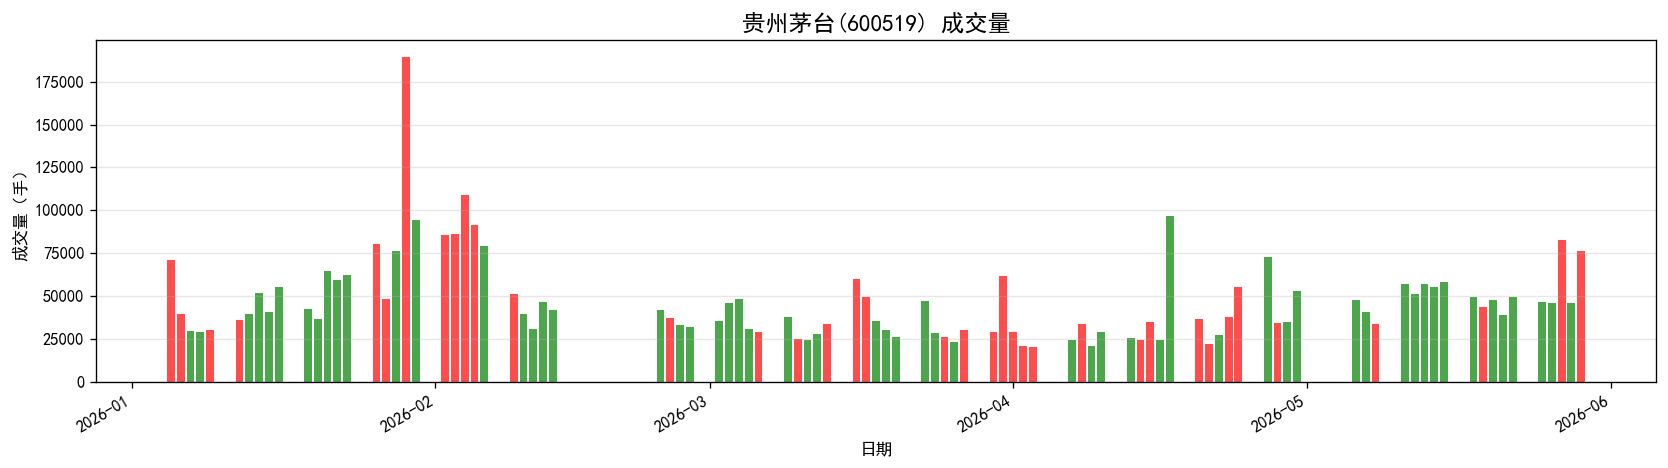

In [25]:
import matplotlib.dates as mdates

colors = ['red' if x >= 0 else 'green' for x in df['涨跌幅']]

fig, ax = plt.subplots(figsize=(14, 4), dpi=120)

# 把日期转成matplotlib能识别的数值
x = mdates.date2num(pd.to_datetime(df['日期']))

ax.bar(x, df['成交量'], color=colors, alpha=0.7, width=0.8)

# 告诉x轴按日期格式显示
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.set_title('贵州茅台(600519) 成交量', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('成交量（手）')
ax.grid(True, alpha=0.3, axis='y')

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('output/returns_dist.png', dpi=120)
plt.show()

日涨跌幅分布直方图

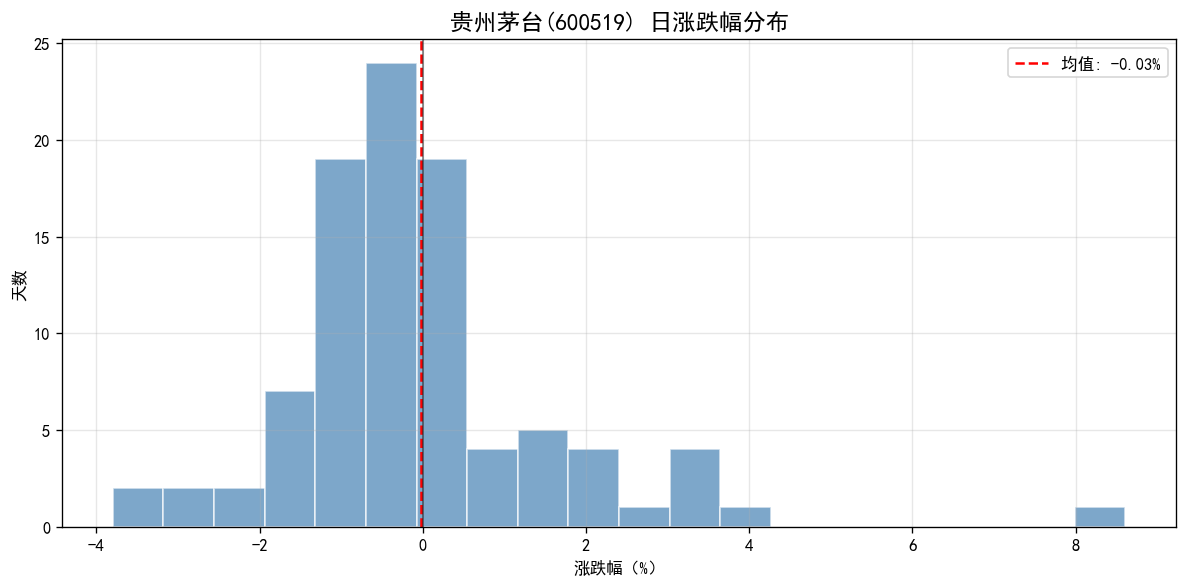

In [19]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

ax.hist(df['涨跌幅'], bins=20, color='steelblue', alpha=0.7, edgecolor='white')

# 加一条均值参考线
mean_return = df['涨跌幅'].mean()
ax.axvline(mean_return, color='red', linestyle='--', linewidth=1.5,
           label=f'均值: {mean_return:.2f}%')

# 加零轴参考线
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.set_title('贵州茅台(600519) 日涨跌幅分布', fontsize=14)
ax.set_xlabel('涨跌幅（%）')
ax.set_ylabel('天数')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/daily_return.png', dpi=120)
plt.show()

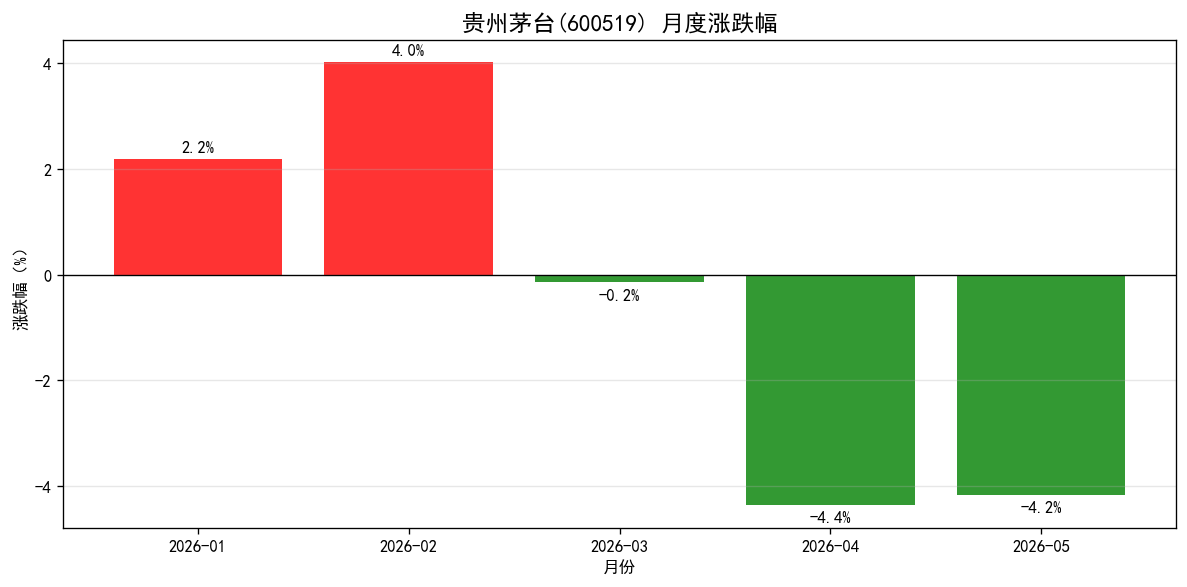

In [22]:
# 提取月份，按月汇总涨跌幅
df['月份'] = pd.to_datetime(df['日期']).dt.to_period('M').astype(str)
monthly = df.groupby('月份')['涨跌幅'].sum().reset_index()
monthly.columns = ['月份', '月度涨跌幅']

colors = ['red' if x >= 0 else 'green' for x in monthly['月度涨跌幅']]

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

bars = ax.bar(monthly['月份'], monthly['月度涨跌幅'], color=colors, alpha=0.8)

# 柱顶显示数值
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('贵州茅台(600519) 月度涨跌幅', fontsize=14)
ax.set_xlabel('月份')
ax.set_ylabel('涨跌幅（%）')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/monthly_return.png', dpi=120)
plt.show()

In [24]:
import pymysql
import pandas as pd

df = pd.read_csv("data/600519_data.csv")

# 连接数据库
conn = pymysql.connect(
    host='localhost',
    port=3306,
    user='root',
    password='你的密码',  # 改成你自己的
    database='stock_analysis',
    charset='utf8mb4'
)

cursor = conn.cursor()

# 逐行插入
insert_sql = """
INSERT INTO stock_daily
(trade_date, stock_code, open_price, close_price, high_price,
 low_price, volume, amount, pct_change, turnover)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

for _, row in df.iterrows():
    cursor.execute(insert_sql, (
        row['日期'],
        row['股票代码'],
        row['开盘'],
        row['收盘'],
        row['最高'],
        row['最低'],
        row['成交量'],
        row['成交额'],
        row['涨跌幅'],
        row['换手率']
    ))

conn.commit()
print(f"写入成功，共 {cursor.rowcount} 行")

cursor.close()
conn.close()

写入成功，共 1 行
